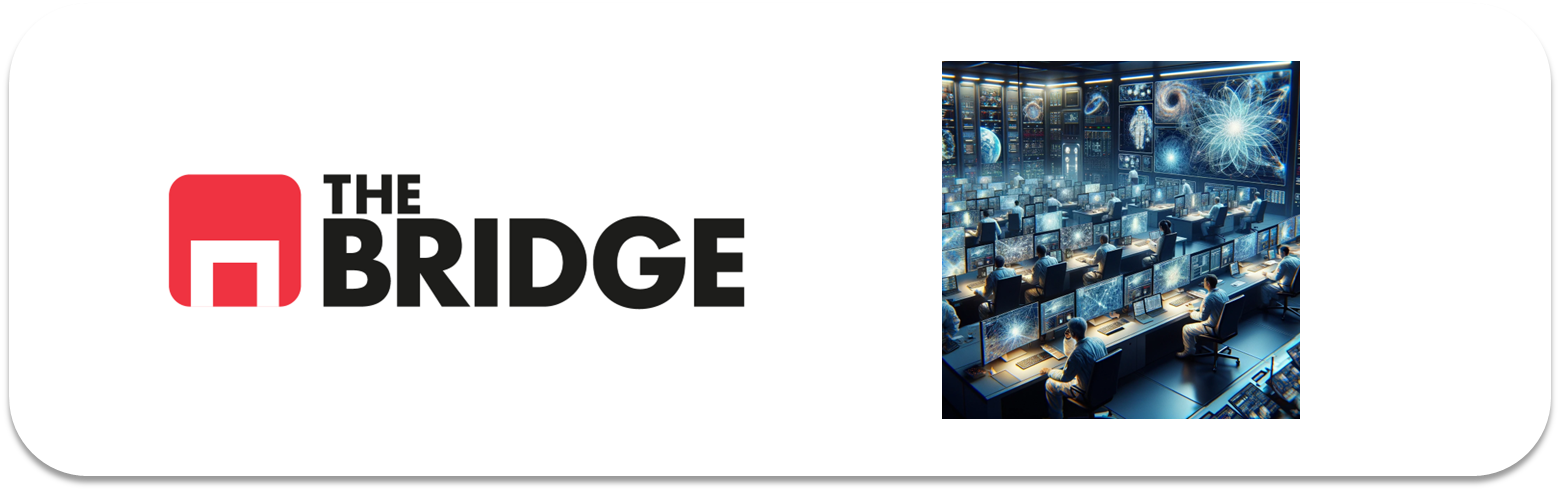

## PRACTICA OBLIGATORIA: **Redes Convolucionales**

* La práctica obligatoria de esta unidad consiste en un ejercicio de construcción de una red convolucional con Keras para la clasificación de imagenes de simpáticos perretes y gatetes. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [2]:
import os
import numpy as np
from PIL import Image

import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Dropout, Flatten, Dense
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

### Problema de Negocio y dataset

Una conocida empresa de información inmobiliaria utiliza un CAPTCHA visual de perros y gatos para detectar webscrappings intensivos y ataques de denegación de servicio. Últimamente, ha detectado que su sistema está empezando a flojear, es decir que hay muchos sistemas de detección automática de imágenes que son capaces de detectar que es un perro y un gato y salterse el CAPTCHA antirobots. Por eso nos ha pedido que entrenemos un modelo potente de clasificación que emule a estos sistemas con el objetivo de emplear como fotografías para el CAPTCHA aquellas que no sepa detectar este sistema emulador de chicos malos.  

Pues manos a la obra, tenemos que seleccionar en un conjunto de 1000 imágenes aquellas que peor se le daría clasificar a un potencial sistema anti-CAPTCHA.  

Para ello vamos a emplear un conjunto de train de 4000 imágenes de perretes y gatetes que se encuentran distribuidas en "data" en cuatro directorios "github_train_0",  "github_train_1", "githun_train_2" y "github_train_3". Los datos de las imagenes que tenemos que clasificar y luego seleccionar como las más "difíciles" están en "data" en el directorio "github_test".


### Se pide

1. Crear los datasets X,y de train y test, leyendo las imágenes de los directorios correspondientes (tendrás que leer todas las imágenes de los cuatro directorios para train) y a la vez que se leen adpatar su resolución para que todas tengan un tamaño de 32x32. En este caso puedes adaptar las funciones de los ejercicios de la unidad. NOTA: Ten en cuenta que la clase a la que pertenece en la foto está en el nombre del archivo.

2. Crea un modelo DL basado en redes convolucionales con al menos dos juegos Convolucional-Pooling. Sigue todo el proceso de ML (visualización del dataset, MiniEDA, Construcción del modelo)

3. Entrenar el modelo con un callback de Earlystopping con paciencia la que tengas :-). Muestra su historial de entrenamiento.

4. Evalua el modelo, haz un reporte de clasificacion y muestra la matriz de confianza.

5. Es el momento de seleccionar las imagenes: Selecciona el 10% de imágenes mal clasificadas de una y otra clase que tengan el mayor nivel de confianza de que pertenencían a la clase errónea. Es decir las imágenes de perros clasificadas como gatos y con la probabilidad de ser perror más alta.


### Extra (para hacer en clase)

Repite los pasos 3 a 5 utilizando el generador de imágenes sintéticas o Image Augmentation de Keras. 



In [3]:
IMG_SIZE = (32, 32)

def load_images_from_dirs(dir_paths, img_size=(32, 32)):
    X, y = [], []
    for d in dir_paths:
        for fname in os.listdir(d):
            if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                continue

            # Etiqueta desde el nombre
            fname_lower = fname.lower()
            if "cat" in fname_lower:
                label = 0
            elif "dog" in fname_lower:
                label = 1
            else:
                continue

            # Cargar imagen
            img = Image.open(os.path.join(d, fname)).convert("RGB")
            img = img.resize(img_size)
            X.append(np.array(img))
            y.append(label)

    X = np.array(X, dtype="float32") / 255.0
    y = np.array(y, dtype="int32")
    return X, y

train_dirs = [
    "data/github_train_0",
    "data/github_train_1",
    "data/github_train_2",
    "data/github_train_3"
]

test_dirs = ["data/github_test"]

X_train, y_train = load_images_from_dirs(train_dirs)
X_test, y_test = load_images_from_dirs(test_dirs)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)


(4000, 32, 32, 3) (4000,)
(1000, 32, 32, 3) (1000,)


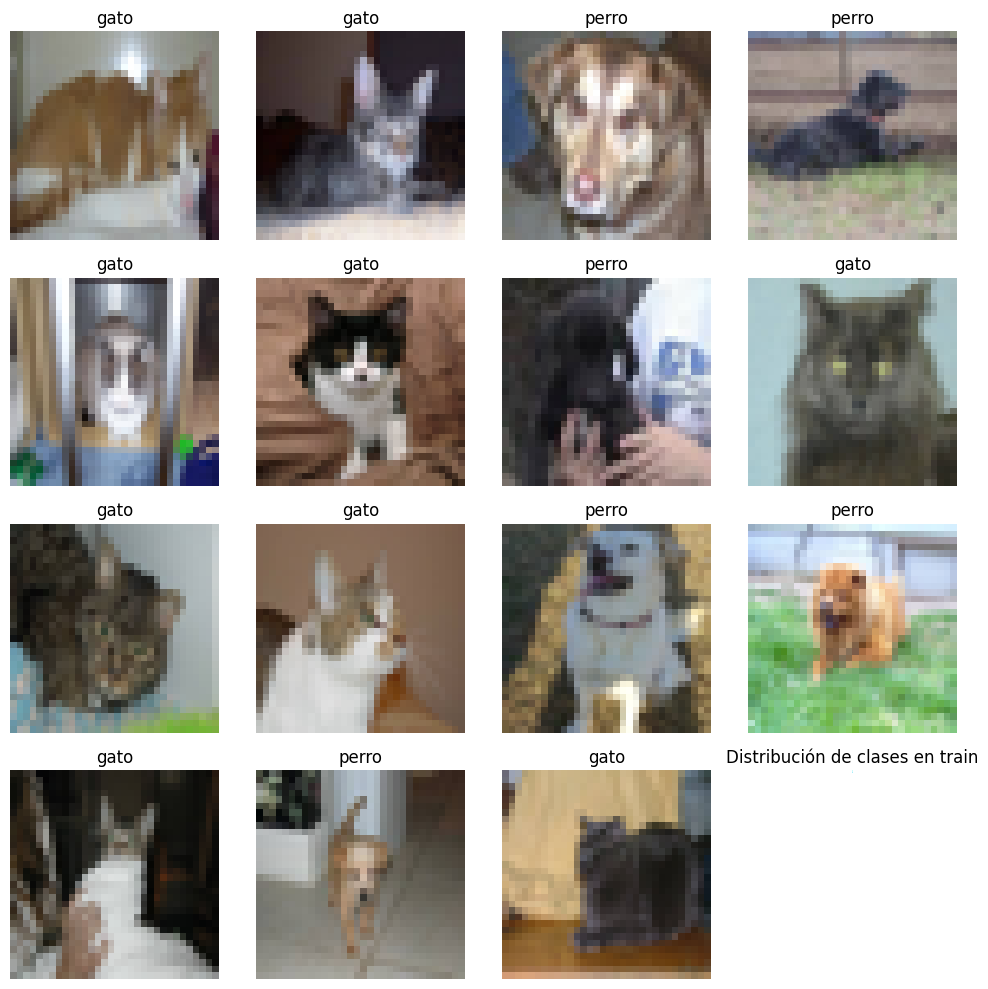

In [4]:
names = ["gato", "perro"]

def plot_samples(X, y, n=16):
    idx = np.random.choice(len(X), n, replace=False)
    n_cols = 4
    n_rows = (n - 1) // n_cols + 1
    plt.figure(figsize=(n_cols*2.5, n_rows*2.5))
    for i, j in enumerate(idx):
        plt.subplot(n_rows, n_cols, i+1)
        plt.imshow(X[j])
        plt.axis('off')
        plt.title(names[y[j]])
    plt.tight_layout()

plot_samples(X_train, y_train, n=16)

sns.countplot(x=y_train)
plt.xticks([0,1], names)
plt.title("Distribución de clases en train");


In [5]:
input_shape = (32, 32, 3)

model = Sequential()

# Bloque 1
model.add(Conv2D(32, (3,3), padding='same', activation='relu', input_shape=input_shape))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Dropout(0.25))

# Bloque 2
model.add(Conv2D(64, (3,3), padding='same', activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Dropout(0.25))

# Bloque 3 opcional (mejora mucho)
model.add(Conv2D(128, (3,3), padding='same', activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Dropout(0.25))

# Cabeza densa
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

model.summary()


c:\Users\César\OneDrive\Escritorio\DS\DS_ONLINE_CESAR\.venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 618,049 (2.36 MB)

 Trainable params: 618,049 (2.36 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [7]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    batch_size=64,
    epochs=50,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.6169 - loss: 0.6721 - val_accuracy: 0.0000e+00 - val_loss: 0.7735
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.6256 - loss: 0.6576 - val_accuracy: 0.0000e+00 - val_loss: 0.9479
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.6369 - loss: 0.6381 - val_accuracy: 0.3075 - val_loss: 0.7811
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.6619 - loss: 0.6094 - val_accuracy: 0.0375 - val_loss: 1.1027
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.6816 - loss: 0.5994 - val_accuracy: 0.5138 - val_loss: 0.7451
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.7106 - loss: 0.5631 - val_accuracy: 0.3438 - val_loss: 0.8874
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.7200 - loss: 0.5559 - val_accuracy: 0.5813 - val_loss: 0.7285
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.7369 - loss: 0.5287 - val_accuracy: 0.

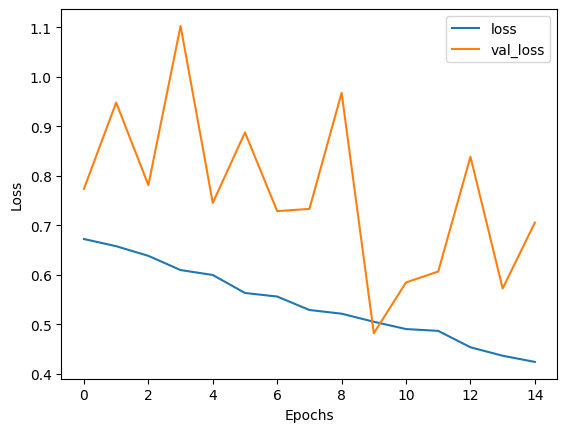

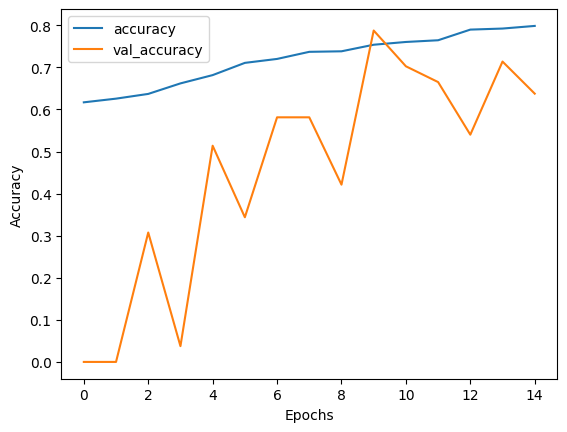

In [8]:
history_df = pd.DataFrame(history.history)
history_df[['loss','val_loss']].plot()
plt.xlabel("Epochs")
plt.ylabel("Loss");

history_df[['accuracy','val_accuracy']].plot()
plt.xlabel("Epochs")
plt.ylabel("Accuracy");


Test loss: 0.5128015279769897
Test accuracy: 0.7400000095367432
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
              precision    recall  f1-score   support

        gato       0.77      0.69      0.73       500
       perro       0.72      0.79      0.75       500

    accuracy                           0.74      1000
   macro avg       0.74      0.74      0.74      1000
weighted avg       0.74      0.74      0.74      1000



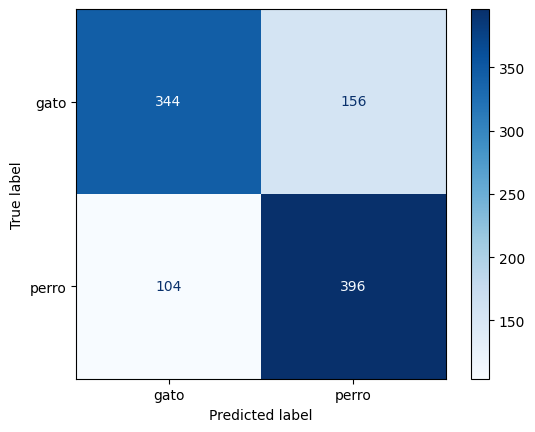

In [9]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

y_proba = model.predict(X_test).ravel()
y_pred = (y_proba >= 0.5).astype(int)

print(classification_report(y_test, y_pred, target_names=names))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=names,
    cmap='Blues'
);


In [10]:
mis_idx = np.where(y_pred != y_test)[0]

# perros → predicho gato
dog_to_cat_idx = mis_idx[(y_test[mis_idx] == 1) & (y_pred[mis_idx] == 0)]
dog_to_cat_conf = 1 - y_proba[dog_to_cat_idx]  # prob de gato

# gatos → predicho perro
cat_to_dog_idx = mis_idx[(y_test[mis_idx] == 0) & (y_pred[mis_idx] == 1)]
cat_to_dog_conf = y_proba[cat_to_dog_idx]  # prob de perro

def top_10_percent(idx_array, conf_array):
    if len(idx_array) == 0:
        return np.array([], dtype=int)
    n = max(1, int(0.1 * len(idx_array)))
    order = np.argsort(conf_array)[::-1]
    return idx_array[order[:n]]

top_dog_to_cat = top_10_percent(dog_to_cat_idx, dog_to_cat_conf)
top_cat_to_dog = top_10_percent(cat_to_dog_idx, cat_to_dog_conf)

print("Perros → gatos (difíciles):", len(top_dog_to_cat))
print("Gatos → perros (difíciles):", len(top_cat_to_dog))


Perros → gatos (difíciles): 10
Gatos → perros (difíciles): 15


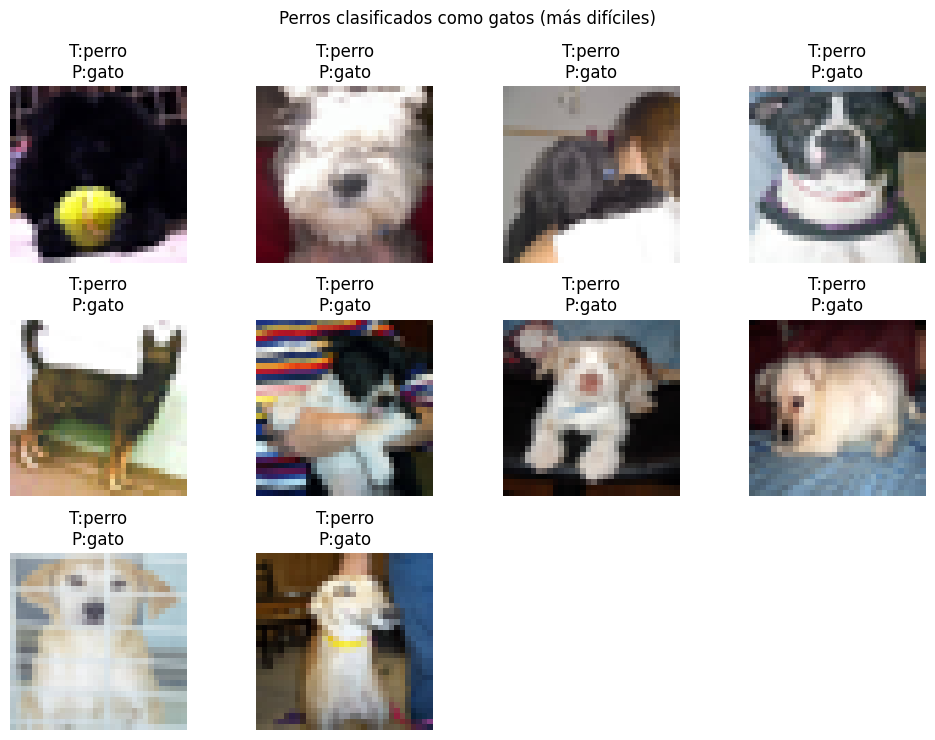

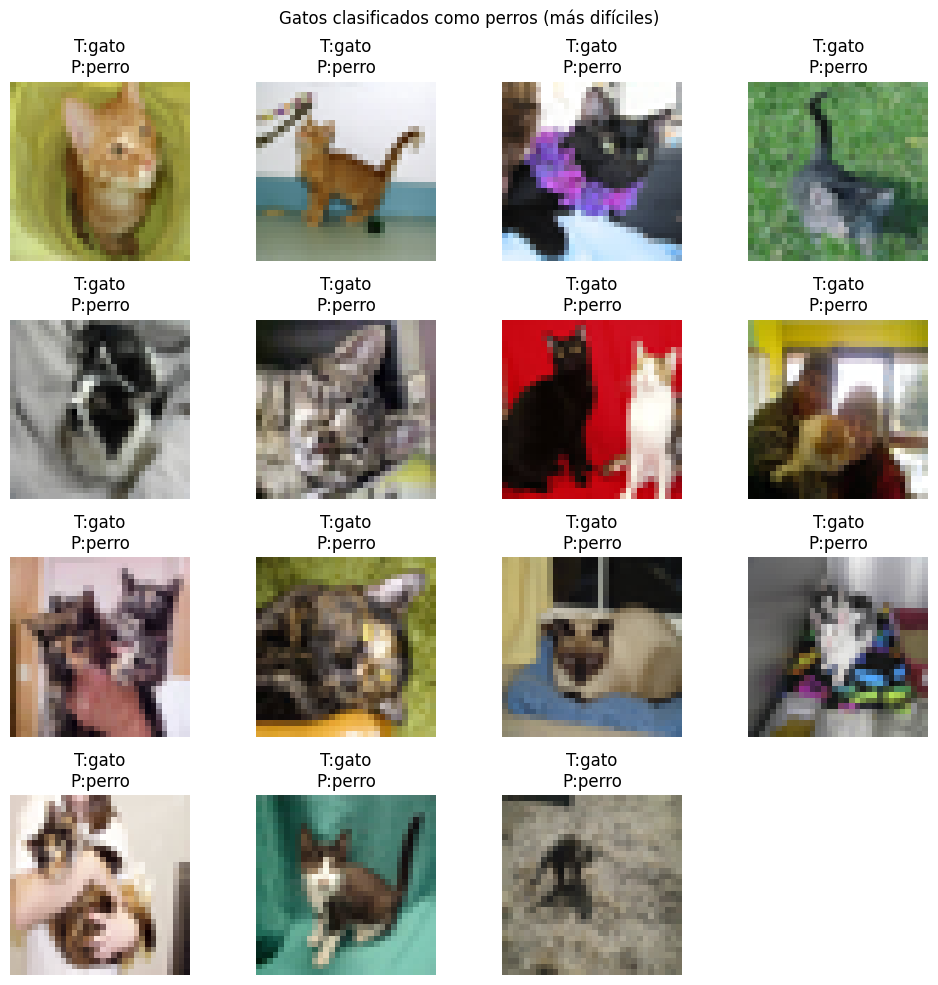

In [11]:
def plot_indices(X, y_true, y_pred, idx, title):
    n = min(len(idx), 16)
    if n == 0:
        print("No hay ejemplos para", title)
        return
    n_cols = 4
    n_rows = (n - 1) // n_cols + 1
    plt.figure(figsize=(n_cols*2.5, n_rows*2.5))
    for i, j in enumerate(idx[:n]):
        plt.subplot(n_rows, n_cols, i+1)
        plt.imshow(X[j])
        plt.axis('off')
        plt.title(f"T:{names[y_true[j]]}\nP:{names[y_pred[j]]}")
    plt.suptitle(title)
    plt.tight_layout()

plot_indices(X_test, y_test, y_pred, top_dog_to_cat,
             "Perros clasificados como gatos (más difíciles)")
plot_indices(X_test, y_test, y_pred, top_cat_to_dog,
             "Gatos clasificados como perros (más difíciles)")


Extra: Entrenamiento con Image Augmentation

In [12]:
from sklearn.model_selection import train_test_split

# Split estratificado
X_train2, X_val, y_train2, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

train_gen = datagen.flow(X_train2, y_train2, batch_size=64)
val_gen = datagen.flow(X_val, y_val, batch_size=64)

history_aug = model.fit(
    train_gen,
    epochs=50,
    validation_data=val_gen,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 99ms/step - accuracy: 0.7072 - loss: 0.5710 - val_accuracy: 0.7312 - val_loss: 0.5391
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 94ms/step - accuracy: 0.7156 - loss: 0.5550 - val_accuracy: 0.6862 - val_loss: 0.5752
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - accuracy: 0.7109 - loss: 0.5500 - val_accuracy: 0.7075 - val_loss: 0.5591
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - accuracy: 0.7266 - loss: 0.5539 - val_accuracy: 0.7075 - val_loss: 0.5594
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 92ms/step - accuracy: 0.7262 - loss: 0.5417 - val_accuracy: 0.7350 - val_loss: 0.5400
